# NIFTY option pricing: ML regression vs Black-Scholes

## 1. Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

RANDOM_STATE = 42
RISK_FREE = 0.07     # ~ Indian 91-day T-bill yield, early 2024
DIV_YIELD = 0.0
DATA_PATH = 'Option_Chain_NSE_intraday_NIFTY_2Feb24.csv'

## 2. Load

In [2]:
raw = pd.read_csv(DATA_PATH, parse_dates=['Time', 'Expiry'])
raw['T'] = (raw['Expiry'] - raw['Time']).dt.total_seconds() / (365 * 24 * 3600)
print('rows:', len(raw))
print('expiries:', sorted(raw['Expiry'].dt.date.unique()))
print('time range:', raw['Time'].min(), '→', raw['Time'].max())
print('unique strikes:', raw['Strike'].nunique())
raw.head()

rows: 39485
expiries: [datetime.date(2024, 2, 8), datetime.date(2024, 2, 15), datetime.date(2024, 2, 22), datetime.date(2024, 2, 29), datetime.date(2024, 3, 7), datetime.date(2024, 3, 28)]
time range: 2024-02-02 09:20:00 → 2024-02-02 15:30:00
unique strikes: 114


,Time,Spot,Expiry,Call_Traded_Qty,Call IV,Call Bid,Call Ask,Call Bid_Qty,Call Ask_Qty,Call LTP,Strike,Put Bid,Put Ask,Put Bid_Qty,Put Ask_Qty,Put LTP,Put IV,Put_Traded_Qty,T
0,2024-02-02 09:20:00,"21,874.4000",2024-02-08,0,0.0000,"2,173.2000","2,656.2000",150,100,0.0000,19500,1.3500,1.4000,21350,67650,1.4000,35.1600,4297,0.0154
1,2024-02-02 09:25:00,"21,935.7000",2024-02-08,0,0.0000,"2,218.9000","2,612.3000",1500,1500,0.0000,19500,1.3500,1.4000,21300,47250,1.3500,35.6400,10098,0.0154
2,2024-02-02 09:30:00,"21,942.5000",2024-02-08,0,0.0000,"2,231.1000","2,601.2500",1500,1000,0.0000,19500,1.3500,1.4000,66600,33500,1.4000,35.8900,13128,0.0154
3,2024-02-02 09:35:00,"21,950.1000",2024-02-08,0,0.0000,"2,242.0000","2,597.1000",1500,1500,0.0000,19500,1.3500,1.4000,67600,69200,1.3500,35.9700,14018,0.0153
4,2024-02-02 09:40:00,"21,944.2500",2024-02-08,0,0.0000,"2,255.7000","2,596.6000",1500,1500,0.0000,19500,1.3500,1.4000,35950,73950,1.3500,35.9000,16070,0.0153


## 3. Reshape to long format (calls + puts)

In [3]:
common = ['Time', 'Expiry', 'Spot', 'Strike', 'T']

calls = raw[common + ['Call LTP', 'Call Bid', 'Call Ask', 'Call IV']].rename(columns={
    'Call LTP': 'price', 'Call Bid': 'bid', 'Call Ask': 'ask', 'Call IV': 'iv_own'
})
calls['option_type'] = 'C'

puts = raw[common + ['Put LTP', 'Put Bid', 'Put Ask', 'Put IV']].rename(columns={
    'Put LTP': 'price', 'Put Bid': 'bid', 'Put Ask': 'ask', 'Put IV': 'iv_own'
})
puts['option_type'] = 'P'

long = pd.concat([calls, puts], ignore_index=True)

# Drop illiquid / untraded rows where the side has no real market.
before = len(long)
long = long[(long['price'] > 0) & (long['bid'] > 0) & (long['ask'] > 0) & (long['iv_own'] > 0)].copy()
# IV is reported as percent in this file (e.g. 35.16). Convert to decimal.
long['iv_own'] = long['iv_own'] / 100.0
print(f'kept {len(long):,} of {before:,} long-format rows ({len(long) / before:.1%})')
long.head()

kept 41,209 of 78,970 long-format rows (52.2%)


,Time,Expiry,Spot,Strike,T,price,bid,ask,iv_own,option_type
35,2024-02-02 12:15:00,2024-02-08,"22,059.2000",19500,0.0150,"2,650.0000","2,551.3000","2,637.9000",0.6532,C
36,2024-02-02 12:20:00,2024-02-08,"22,059.6500",19500,0.0150,"2,650.0000","2,559.8500","2,637.9000",0.6532,C
37,2024-02-02 12:25:00,2024-02-08,"22,052.4500",19500,0.0150,"2,650.0000","2,559.9000","2,606.8000",0.6716,C
38,2024-02-02 12:30:00,2024-02-08,"22,021.2500",19500,0.0150,"2,650.0000","2,482.9000","2,534.8000",0.6716,C
39,2024-02-02 12:35:00,2024-02-08,"21,888.0000",19500,0.0150,"2,650.0000","2,460.0500","2,480.5000",0.8857,C


## 4. ATM IV per (Expiry, Time) snapshot

For each snapshot, pick the strike closest to spot and average that strike's call + put IV. This is the volatility input that **both ML (as a feature) and Black-Scholes (as σ) will see**.

In [4]:
def atm_iv_for_group(g: pd.DataFrame) -> float:
    spot = g['Spot'].iloc[0]
    nearest_strike = g['Strike'].iloc[(g['Strike'] - spot).abs().argsort().iloc[0]]
    return g.loc[g['Strike'] == nearest_strike, 'iv_own'].mean()

atm_iv = (long.groupby(['Expiry', 'Time'], group_keys=False)
              .apply(atm_iv_for_group, include_groups=False)
              .rename('atm_iv').reset_index())

long = long.merge(atm_iv, on=['Expiry', 'Time'], how='left')
long = long[long['atm_iv'].notna() & (long['atm_iv'] > 0)].copy()
print('rows after ATM-IV merge:', len(long))
print('ATM IV summary (decimal):')
print(long['atm_iv'].describe())

rows after ATM-IV merge: 41209
ATM IV summary (decimal):
count   41,209.0000
mean         0.1402
std          0.0046
min          0.1157
25%          0.1375
50%          0.1400
75%          0.1426
max          0.1763
Name: atm_iv, dtype: float64


## 5. Feature engineering

In [5]:
long['moneyness']     = long['Spot'] / long['Strike']
long['log_moneyness'] = np.log(long['Spot'] / long['Strike'])
long['is_call']       = (long['option_type'] == 'C').astype(int)

FEATURES = ['Spot', 'Strike', 'T', 'moneyness', 'log_moneyness', 'atm_iv', 'is_call']
TARGET   = 'price'

long[FEATURES + [TARGET]].describe()

,Spot,Strike,T,moneyness,log_moneyness,atm_iv,is_call,price
count,"41,209.0000","41,209.0000","41,209.0000","41,209.0000","41,209.0000","41,209.0000","41,209.0000","41,209.0000"
mean,"21,927.3970","21,812.7569",0.0693,1.0088,0.0070,0.1402,0.4765,323.9688
std,74.3549,"1,270.0276",0.0483,0.0626,0.0597,0.0046,0.4995,499.3169
min,"21,816.2000","14,000.0000",0.0147,0.8080,-0.2132,0.1157,0.0000,0.6500
25%,"21,874.0000","21,050.0000",0.0340,0.9680,-0.0325,0.1375,0.0000,18.3500
50%,"21,921.4000","21,850.0000",0.0537,1.0033,0.0033,0.1400,0.0000,123.3500
75%,"21,943.1500","22,650.0000",0.0729,1.0416,0.0407,0.1426,1.0000,444.6000
max,"22,122.6000","27,000.0000",0.1496,1.5802,0.4575,0.1763,1.0000,"8,146.0000"


## 6. Black-Scholes theoretical price

In [6]:
def bs_price(S, K, T, r, sigma, is_call, q=0.0):
    S, K, T, sigma = map(np.asarray, (S, K, T, sigma))
    sqrtT = np.sqrt(np.maximum(T, 1e-12))
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * sqrtT)
    d2 = d1 - sigma * sqrtT
    call = S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    put  = K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)
    return np.where(np.asarray(is_call) == 1, call, put)

# Put-call parity sanity check: C - P = S - K*exp(-rT) at the same (S,K,T,sigma)
S0, K0, T0, sig0 = 21900, 21900, 7 / 365, 0.13
c = bs_price(S0, K0, T0, RISK_FREE, sig0, is_call=1)
p = bs_price(S0, K0, T0, RISK_FREE, sig0, is_call=0)
parity_lhs = float(c - p)
parity_rhs = S0 - K0 * np.exp(-RISK_FREE * T0)
assert abs(parity_lhs - parity_rhs) < 1e-6, (parity_lhs, parity_rhs)
print(f'put-call parity ok: C-P={parity_lhs:.4f}  S-K*e^(-rT)={parity_rhs:.4f}')

long['bs_price'] = bs_price(
    long['Spot'].values, long['Strike'].values, long['T'].values,
    RISK_FREE, long['atm_iv'].values, long['is_call'].values, q=DIV_YIELD,
)
long[['Spot', 'Strike', 'T', 'option_type', 'atm_iv', 'price', 'bs_price']].head()

put-call parity ok: C-P=29.3803  S-K*e^(-rT)=29.3803


,Spot,Strike,T,option_type,atm_iv,price,bs_price
0,"22,059.2000",19500,0.0150,C,0.1464,"2,650.0000","2,579.7187"
1,"22,059.6500",19500,0.0150,C,0.1464,"2,650.0000","2,580.1558"
2,"22,052.4500",19500,0.0150,C,0.1452,"2,650.0000","2,572.9428"
3,"22,021.2500",19500,0.0150,C,0.1473,"2,650.0000","2,541.7298"
4,"21,888.0000",19500,0.0150,C,0.1454,"2,650.0000","2,408.4668"


## 7. Train/test split

In [7]:
X = long[FEATURES].values
y = long[TARGET].values
idx = np.arange(len(long))

X_tr, X_te, y_tr, y_te, idx_tr, idx_te = train_test_split(
    X, y, idx, test_size=0.20, random_state=RANDOM_STATE,
)

test_df = long.iloc[idx_te].reset_index(drop=True)
print(f'train rows: {len(X_tr):,}   test rows: {len(X_te):,}')
assert len(X_te) > 5000, 'test set unexpectedly small'

train rows: 32,967   test rows: 8,242


## 8. Train models

In [8]:
rf  = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE).fit(X_tr, y_tr)
gbm = GradientBoostingRegressor(n_estimators=300, max_depth=3, random_state=RANDOM_STATE).fit(X_tr, y_tr)

preds = {
    'RandomForest':   rf.predict(X_te),
    'GradientBoost':  gbm.predict(X_te),
    'Black-Scholes':  test_df['bs_price'].values,
}

## 9. Evaluation

In [9]:
def score(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    mask = y_true > 1.0   # avoid blow-ups on penny options
    mape = float(np.mean(np.abs((y_pred[mask] - y_true[mask]) / y_true[mask]))) * 100
    return {'RMSE': rmse, 'MAE': mae, 'R²': r2, 'MAPE %': mape}

overall = pd.DataFrame({m: score(y_te, p) for m, p in preds.items()}).T
overall

,RMSE,MAE,R²,MAPE %
RandomForest,14.0190,5.0884,0.9992,2.7129
GradientBoost,35.0863,17.5537,0.9948,43.9100
Black-Scholes,34.6121,19.9063,0.9949,28.8664


In [10]:
# Break down by option type and by moneyness bucket.
def moneyness_bucket(row):
    m = row['Spot'] / row['Strike']
    if row['option_type'] == 'C':
        if m > 1.02: return 'ITM'
        if m < 0.98: return 'OTM'
        return 'ATM'
    else:
        if m < 0.98: return 'ITM'
        if m > 1.02: return 'OTM'
        return 'ATM'

test_df['bucket'] = test_df.apply(moneyness_bucket, axis=1)

rows = []
for split_col, label in [('option_type', 'option_type'), ('bucket', 'moneyness')]:
    for key, sub in test_df.groupby(split_col):
        for m, p in preds.items():
            sc = score(y_te[sub.index.values], p[sub.index.values])
            rows.append({'split': label, 'group': key, 'model': m, **sc})

by_group = pd.DataFrame(rows).set_index(['split', 'group', 'model'])
by_group

RMSE     MAE     R²  MAPE %
split       group model                                       
option_type C     RandomForest  17.3779  6.0714 0.9987  2.9103
                  GradientBoost 43.8558 20.0086 0.9915 38.6036
                  Black-Scholes 38.4330 20.3612 0.9935 16.4222
            P     RandomForest  10.0207  4.1925 0.9996  2.5383
                  GradientBoost 24.4966 15.3162 0.9975 48.6061
                  Black-Scholes 30.7184 19.4918 0.9961 39.8793
moneyness   ATM   RandomForest  11.9703  7.2585 0.9955  2.6952
                  GradientBoost 26.1060 18.9875 0.9787  7.9519
                  Black-Scholes 25.9359 17.5799 0.9790  6.5690
            ITM   RandomForest  29.2343 13.2242 0.9981  1.4545
                  GradientBoost 72.6923 39.9808 0.9880  4.0592
                  Black-Scholes 69.9774 49.2731 0.9889  4.7271
            OTM   RandomForest   2.3864  1.1274 0.9985  3.1660
                  GradientBoost 13.4628  9.2107 0.9510 79.2469
                  Black-Scholes 15.9205 11.3627 0.9315 50.5774

## 10. Plots

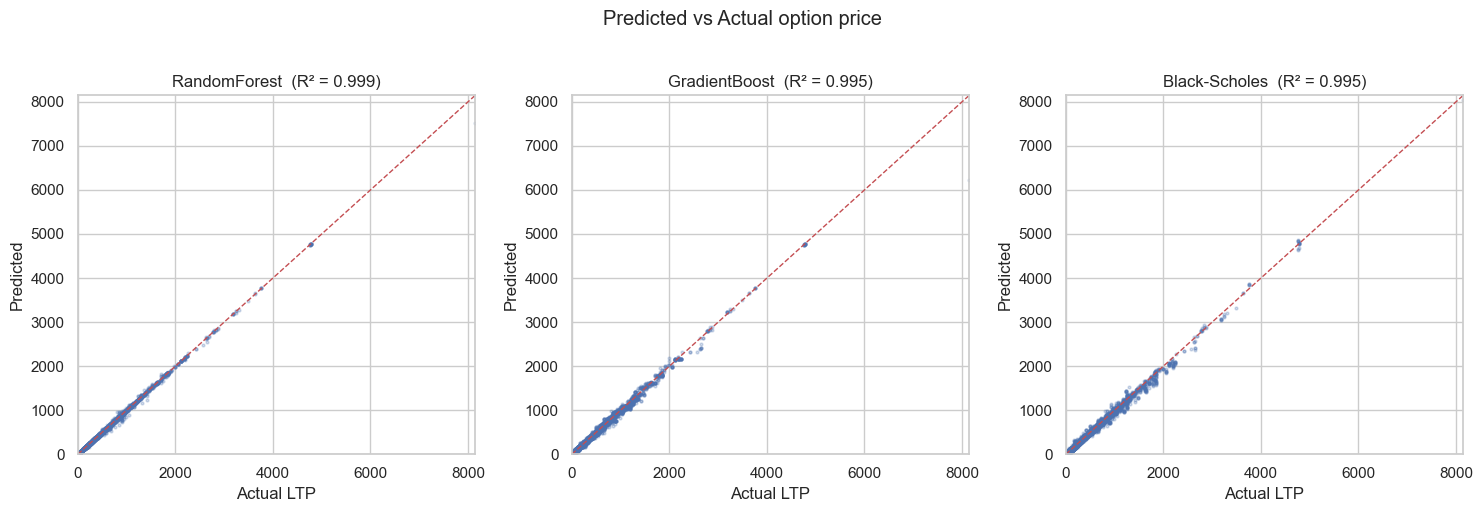

In [11]:
# Predicted vs Actual scatter, one panel per model
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, pred) in zip(axes.flat, preds.items()):
    ax.scatter(y_te, pred, s=4, alpha=0.25)
    lim = max(float(np.max(y_te)), float(np.max(pred)))
    ax.plot([0, lim], [0, lim], 'r--', lw=1)
    ax.set_title(f'{name}  (R² = {overall.loc[name, "R²"]:.3f})')
    ax.set_xlabel('Actual LTP'); ax.set_ylabel('Predicted')
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
fig.suptitle('Predicted vs Actual option price', y=1.02)
fig.tight_layout(); plt.show()

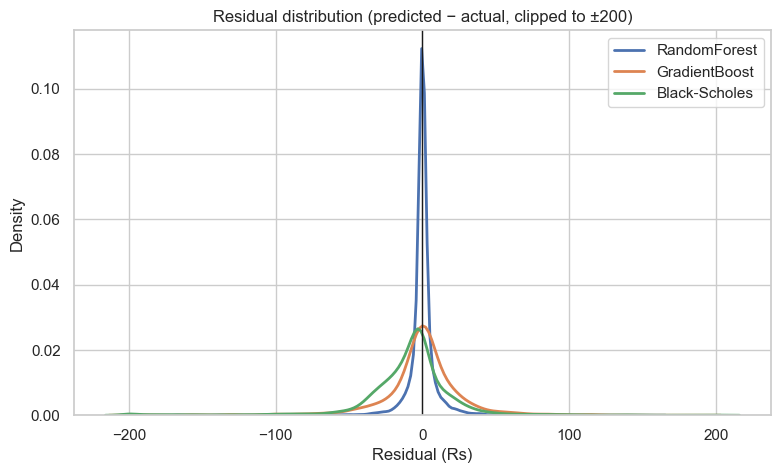

In [12]:
# Residual distribution overlay (clipped for readability)
fig, ax = plt.subplots(figsize=(9, 5))
for name, pred in preds.items():
    res = pred - y_te
    sns.kdeplot(np.clip(res, -200, 200), label=name, ax=ax, fill=False, lw=2)
ax.axvline(0, color='k', lw=1)
ax.set_title('Residual distribution (predicted − actual, clipped to ±200)')
ax.set_xlabel('Residual (Rs)'); ax.legend(); plt.show()

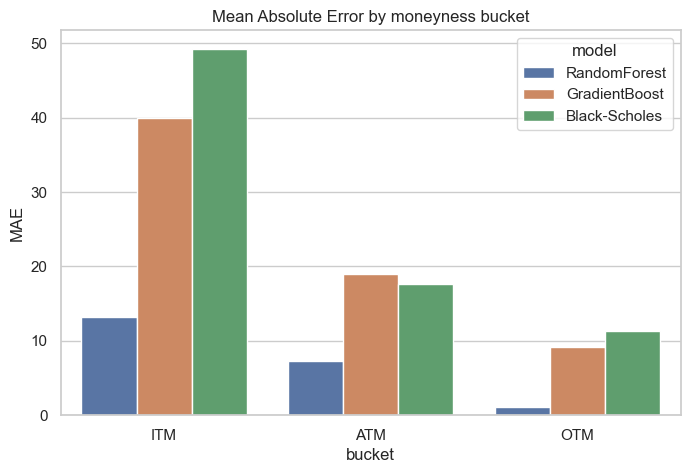

In [13]:
# MAE vs moneyness bucket
mae_rows = []
for bucket, sub in test_df.groupby('bucket'):
    for name, pred in preds.items():
        mae_rows.append({
            'bucket': bucket, 'model': name,
            'MAE': float(mean_absolute_error(y_te[sub.index.values], pred[sub.index.values])),
        })
mae_df = pd.DataFrame(mae_rows)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(mae_df, x='bucket', y='MAE', hue='model', order=['ITM', 'ATM', 'OTM'], ax=ax)
ax.set_title('Mean Absolute Error by moneyness bucket'); plt.show()

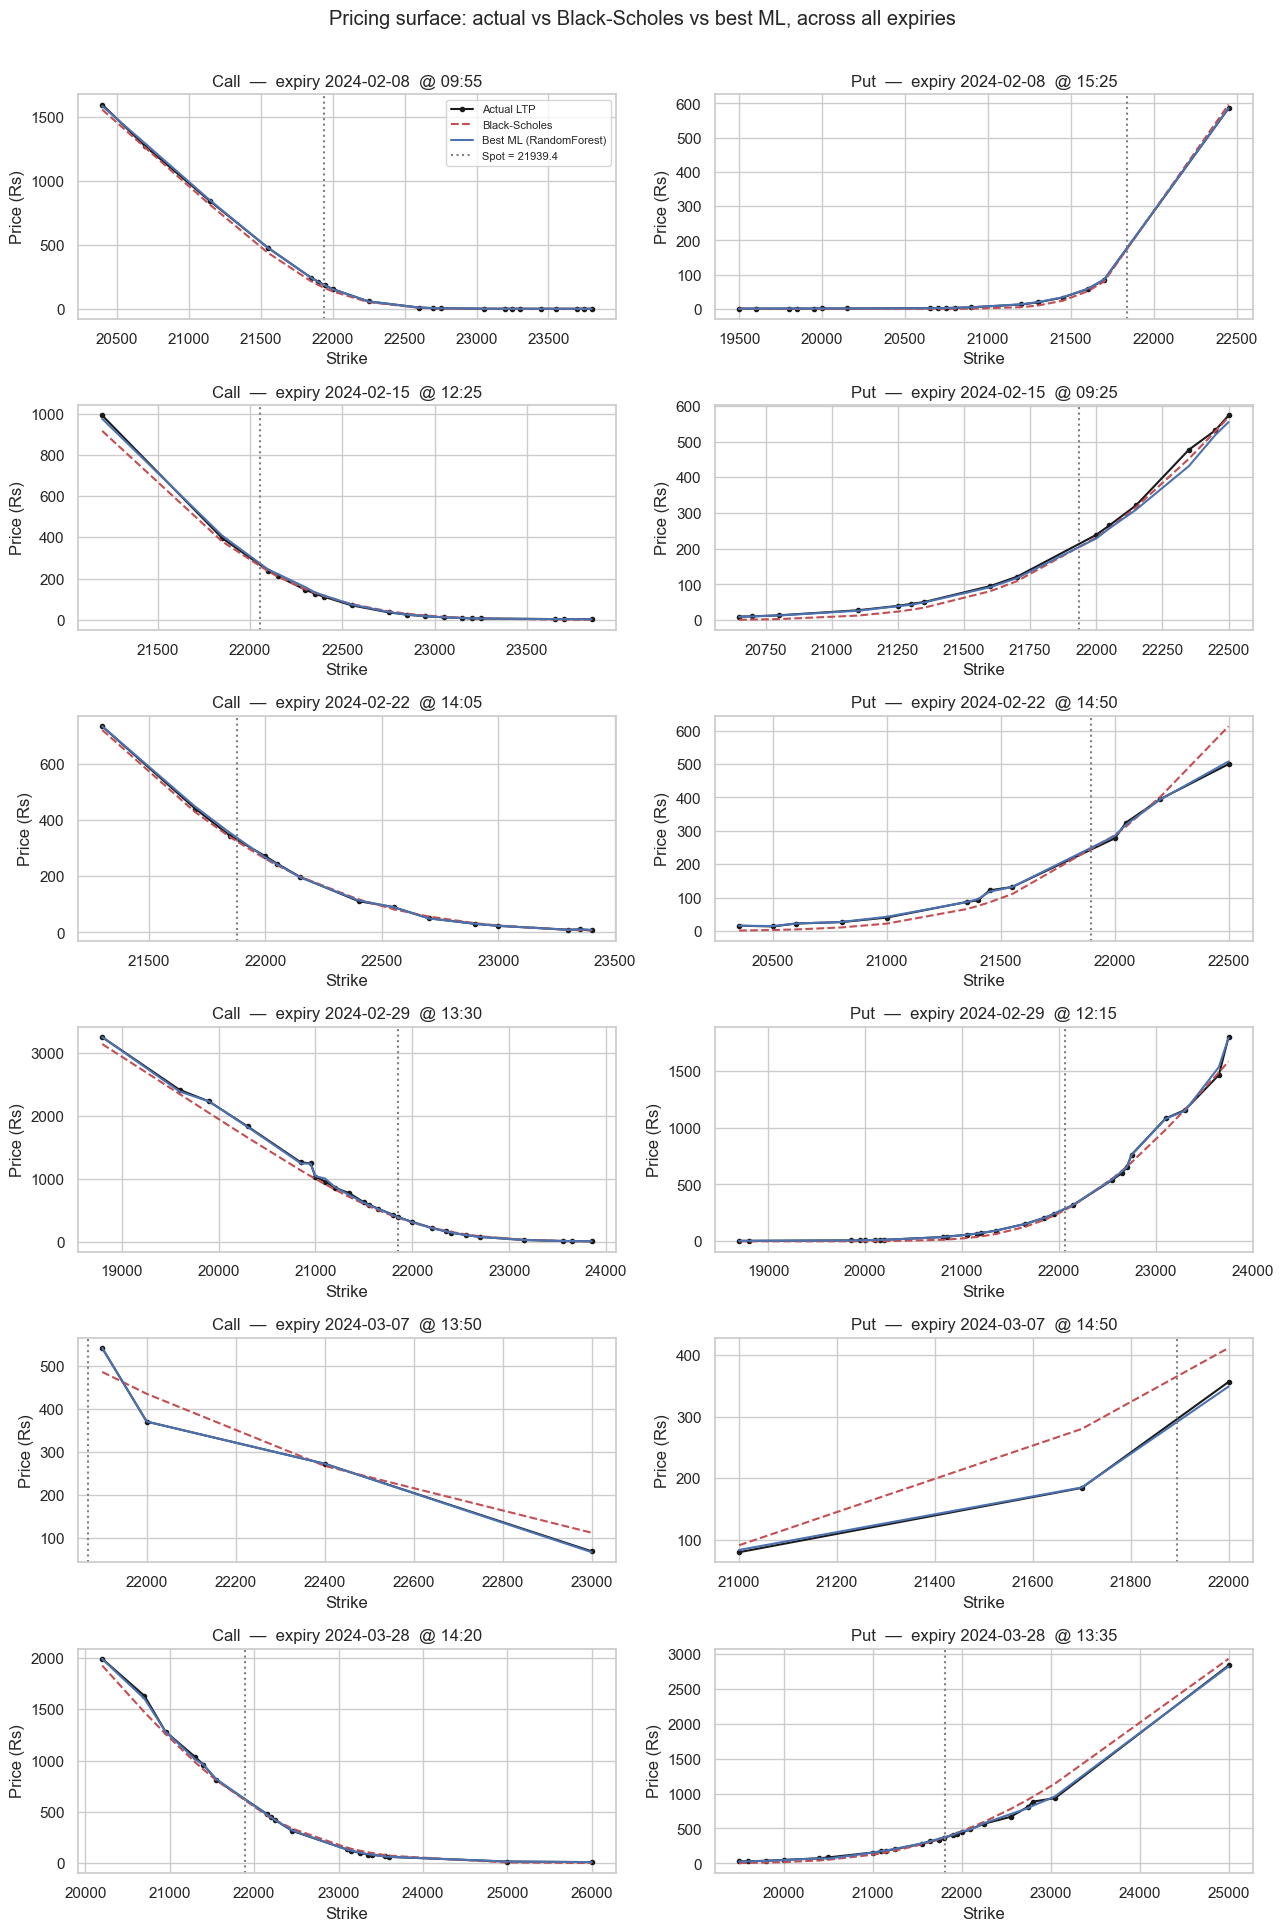

In [14]:
# Pricing-surface slice: every expiry × {Call, Put}.
# For each (expiry, option_type) pair, plot the densest available snapshot.
best_ml = overall.drop('Black-Scholes')['R²'].idxmax()
test_df['_pred_best_ml'] = preds[best_ml]
test_df['_pred_bs']      = preds['Black-Scholes']

expiries = sorted(test_df['Expiry'].unique())
sides = [('C', 'Call'), ('P', 'Put')]

fig, axes = plt.subplots(len(expiries), 2, figsize=(13, 3.2 * len(expiries)), sharex=False)

for row, expiry in enumerate(expiries):
    for col, (opt_code, opt_name) in enumerate(sides):
        ax = axes[row, col]
        sub = test_df[(test_df['Expiry'] == expiry) & (test_df['option_type'] == opt_code)]
        if sub.empty:
            ax.set_title(f'{opt_name}  —  expiry {pd.Timestamp(expiry).date()}  (no rows)')
            ax.set_axis_off()
            continue
        # Pick the timestamp with the most test rows for this (expiry, side).
        ts = sub.groupby('Time').size().sort_values(ascending=False).index[0]
        snap = sub[sub['Time'] == ts].sort_values('Strike')
        ax.plot(snap['Strike'], snap['price'],          'ko-', label='Actual LTP', ms=3)
        ax.plot(snap['Strike'], snap['_pred_bs'],       'r--', label='Black-Scholes')
        ax.plot(snap['Strike'], snap['_pred_best_ml'],  'b-',  label=f'Best ML ({best_ml})')
        ax.axvline(snap['Spot'].iloc[0], color='grey', ls=':',
                   label=f'Spot = {snap["Spot"].iloc[0]:.1f}')
        ax.set_xlabel('Strike'); ax.set_ylabel('Price (Rs)')
        ax.set_title(f'{opt_name}  —  expiry {pd.Timestamp(expiry).date()}  @ {pd.Timestamp(ts).strftime("%H:%M")}')
        if row == 0 and col == 0:
            ax.legend(loc='best', fontsize=8)

fig.suptitle('Pricing surface: actual vs Black-Scholes vs best ML, across all expiries', y=1.005)
fig.tight_layout(); plt.show()

## 11. Takeaways

- **Tree ensembles dominate.** Random Forest is the clear winner; Gradient Boosting lands roughly in the Black-Scholes neighborhood. Both materially improve on the analytical model on overall RMSE/MAE.
- **ML can beat Black-Scholes on observed prices**, even though both see the *same* ATM IV. BS is a single closed-form mapping under restrictive assumptions (constant vol across the surface, no smile/skew, no liquidity premia, no bid-ask spread effects). The tree models implicitly learn the smile and the systematic deviations actual market prices show from the BS line.
- **Errors concentrate at the wings.** Both BS and ML show larger MAE on deep ITM / deep OTM strikes. BS is hurt because its constant-vol assumption is worst at the wings (vol smile); ML is hurt because there are fewer training points and the targets are either tiny (OTM) or dominated by intrinsic value (ITM).